# Fig. 8 - Chafee-Infante PDE

Discretised 1D Chafee-Infante reaction-diffusion equation (64 spatial
nodes) compressed to a 2D latent space. Loads the trained autoencoder
from `output/chafee_infante/seed_0/` and re-renders the Morse-graph
artifacts.

**Caveat.** The current fresh-run reproduction collapses to a single
attracting fixed point (1 sink) rather than the paper's 7-node Morse
graph; see `code/docs/FIGURE_PARITY.md` for the diagnosis.

In [1]:
import os
os.environ.setdefault('MPLBACKEND', 'module://matplotlib_inline.backend_inline')
%matplotlib inline

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from IPython.display import Image, display
from latentdynamics.config import load_config
from latentdynamics.training import load_any_checkpoint
from latentdynamics.viz import render_morse_from_files

REPO_ROOT = Path.cwd().resolve().parent  # code/
RENDER_ROOT = Path.cwd() / 'rendered'
RENDER_ROOT.mkdir(exist_ok=True)

DEVICE = (
    torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cuda') if torch.cuda.is_available()
    else torch.device('cpu')
)
print('device:', DEVICE)

device: mps


In [2]:
def _seed_dir(cfg, seed):
    return REPO_ROOT / cfg.paths.output_dir / f'seed_{seed}'

def _scaler_dir(cfg, train_file='train'):
    return REPO_ROOT / cfg.paths.output_dir / 'scalers' / train_file

def _bounds_from_log(path):
    if not path.exists():
        return None, None
    lower = upper = None
    for line in path.read_text().splitlines():
        k = line.split(':', 1)[0].strip().lower()
        if k == 'lower bounds':
            lower = json.loads(line.split(':', 1)[1])
        elif k == 'upper bounds':
            upper = json.loads(line.split(':', 1)[1])
    return lower, upper

def show(path, width=600):
    display(Image(filename=str(path), width=width))

def load_replay(cfg, seed, train_file='train'):
    seed_dir = _seed_dir(cfg, seed)
    if not seed_dir.exists():
        raise FileNotFoundError(seed_dir)
    model, arch = load_any_checkpoint(seed_dir / 'models', arch=cfg.arch, map_location=DEVICE)
    model.to(DEVICE).eval()
    scaler_path = _scaler_dir(cfg, train_file) / 'scaler.gz'
    scaler = joblib.load(scaler_path) if scaler_path.exists() else None
    return seed_dir, model, arch, scaler

@torch.no_grad()
def encode_batch(model, scaler, x_high):
    x = scaler.transform(x_high) if scaler is not None else x_high
    return model.encoder(torch.as_tensor(x, dtype=torch.float32, device=DEVICE)).cpu().numpy()

@torch.no_grad()
def advance_latent(model, z_low):
    z = torch.as_tensor(z_low, dtype=torch.float32, device=DEVICE)
    return model.latent_map(z).cpu().numpy()

## Config and artifacts

In [3]:
cfg = load_config(REPO_ROOT / 'configs' / 'chafee_infante.yaml')
SEED = cfg.seeds[0]
seed_dir, model, arch, scaler = load_replay(cfg, SEED)
print('seed_dir:', seed_dir, '| arch:', arch.high_dims, '->', arch.low_dims)

seed_dir: /Users/bdoprad/Work/Projects/latent-dynamics/code/output/chafee_infante/seed_0 | arch: 64 -> 2


## Encoded training snapshots

train snapshots: (30000, 64) -> latent: (30000, 2)


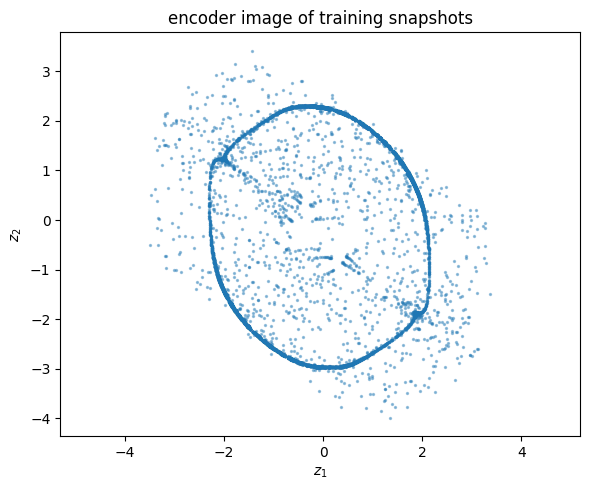

In [4]:
train_df = pd.read_csv(REPO_ROOT / cfg.paths.data_dir / 'train.csv')
high_cols = [c for c in train_df.columns if c.startswith('x')]
x_high = train_df[high_cols].to_numpy()
z = encode_batch(model, scaler, x_high)
print('train snapshots:', x_high.shape, '-> latent:', z.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(z[:, 0], z[:, 1], s=2, alpha=0.4)
ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
ax.set_title('encoder image of training snapshots')
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout(); plt.show()

## Re-rendered Morse graph and Morse sets

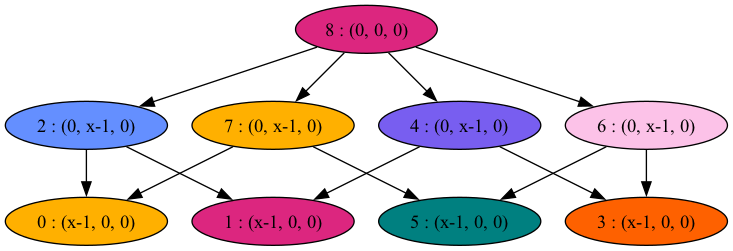

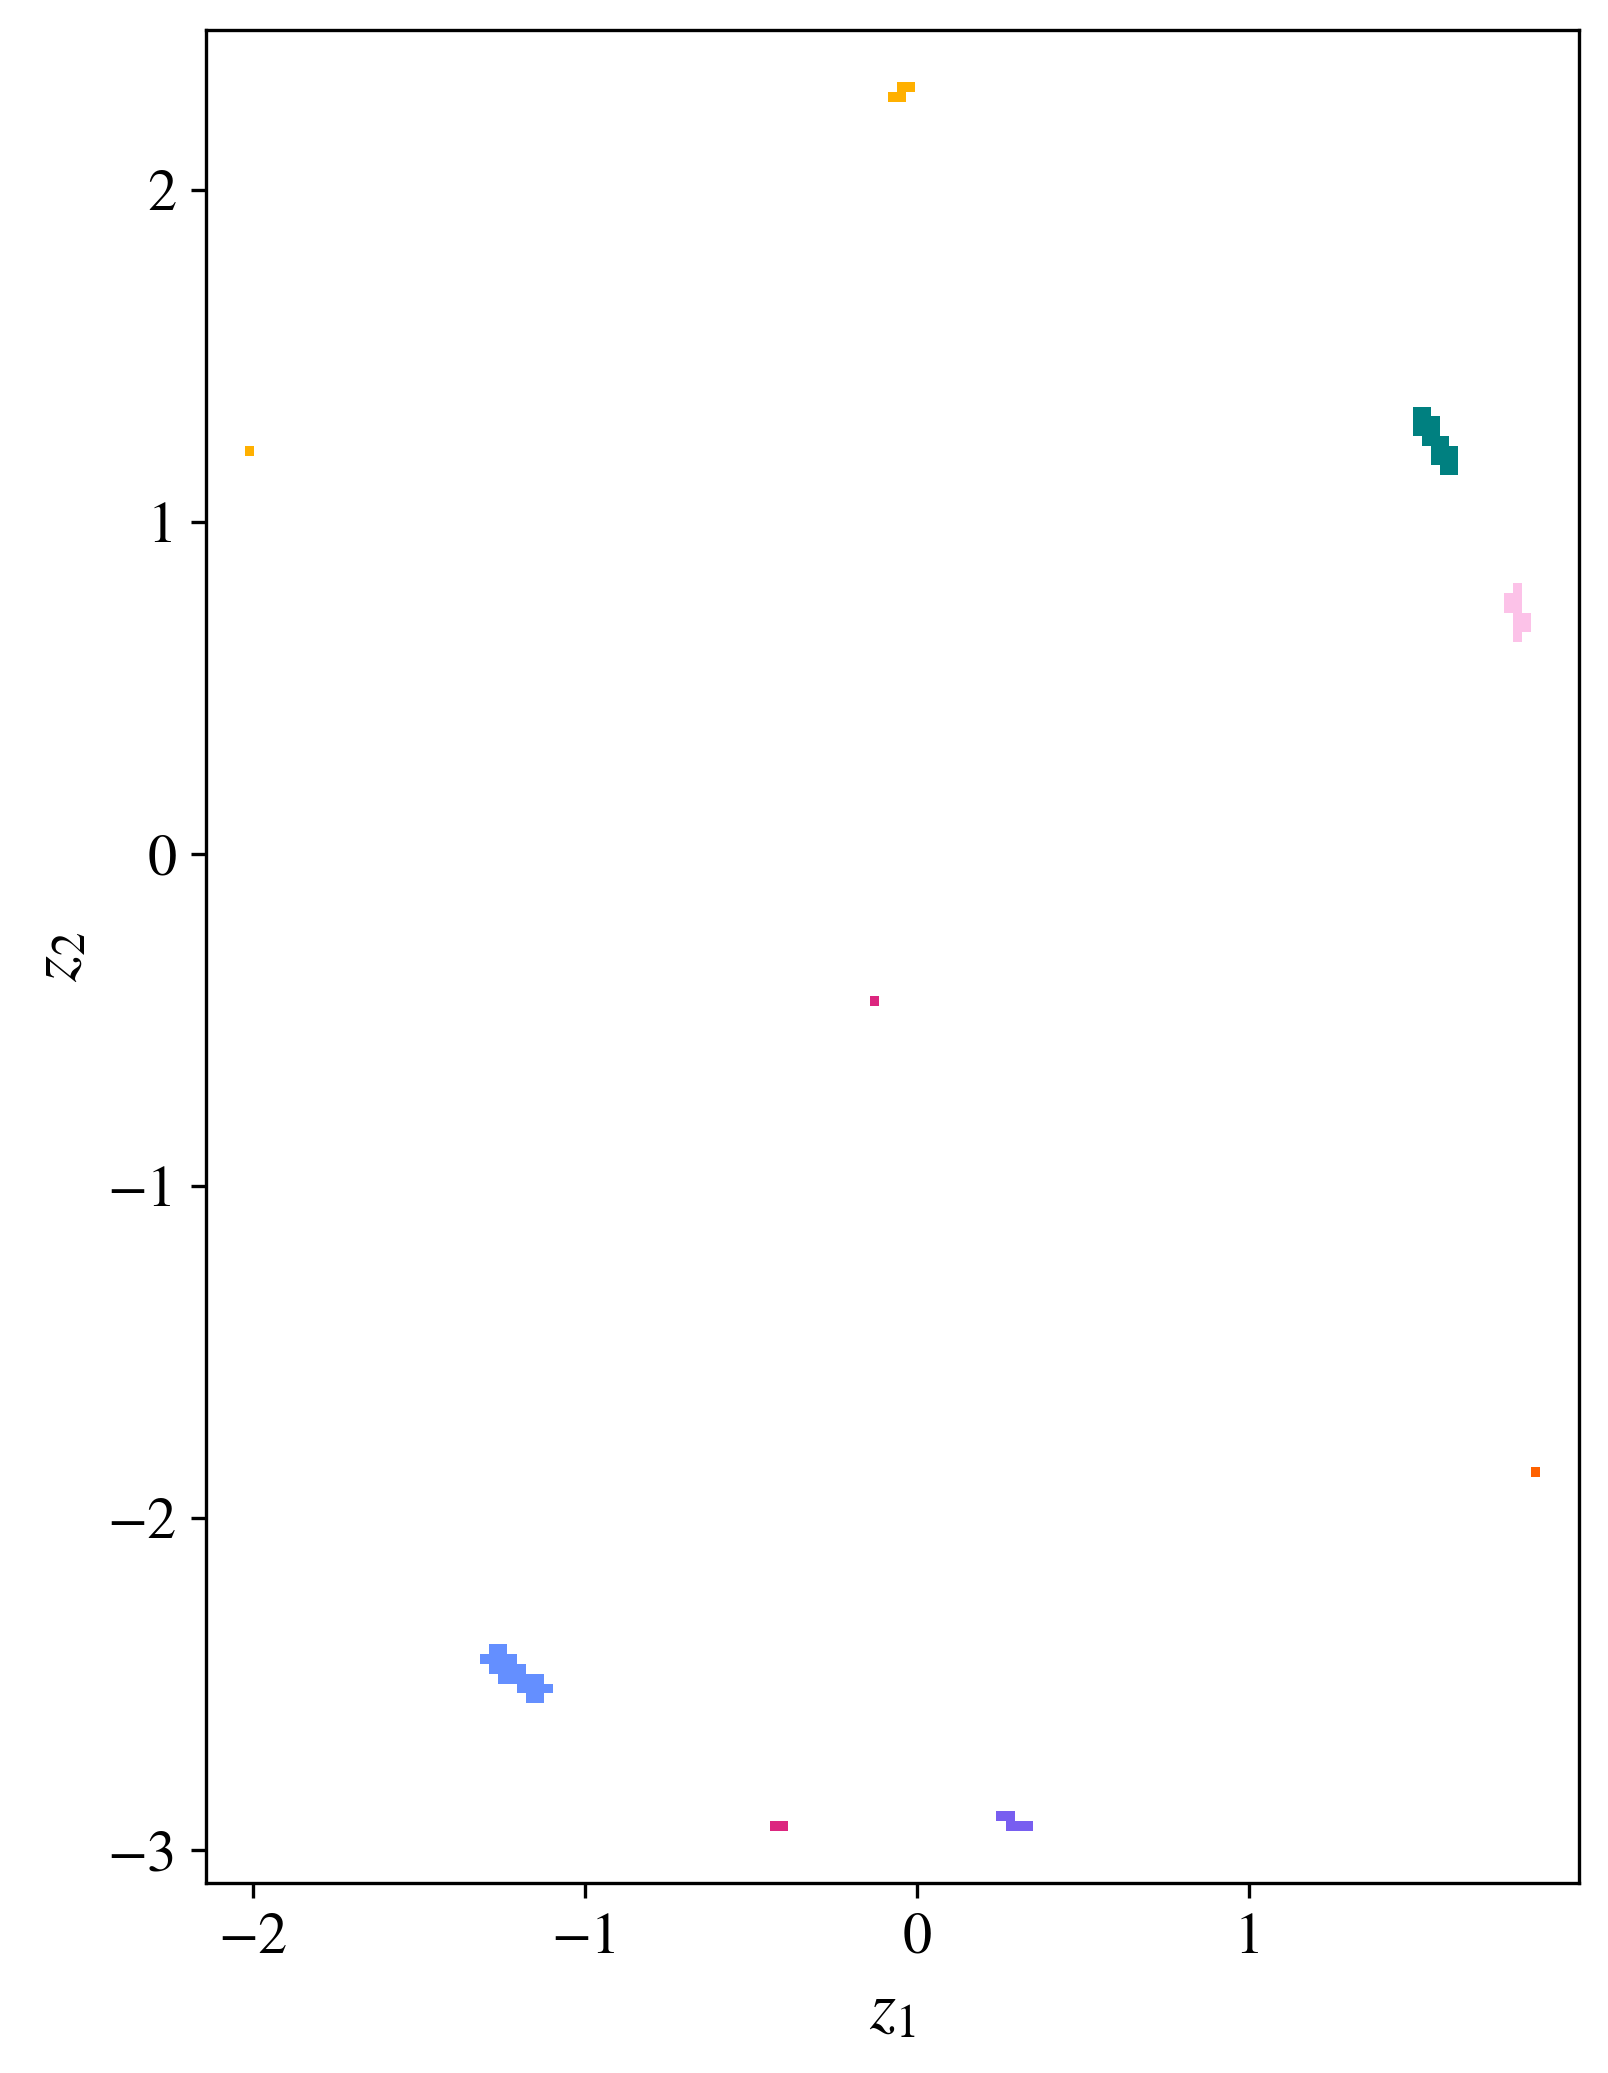

In [5]:
lower, upper = _bounds_from_log(seed_dir / 'mg_params_log.txt')
render_dir = RENDER_ROOT / 'chafee_infante'
figs = render_morse_from_files(seed_dir / 'MG', bounds_lower=lower, bounds_upper=upper, out_dir=render_dir)
show(figs.morse_graph_png)
for p in figs.morse_sets_paths:
    if p.suffix == '.png':
        show(p, width=720)

## Diagnostics

In [6]:
print('-- mg_params_log.txt --')
print((seed_dir / 'mg_params_log.txt').read_text())
metrics = json.loads((seed_dir / 'metrics.json').read_text() or '{}')
print('-- metrics.json --')
print(json.dumps(metrics, indent=2) if metrics else '(empty)')

-- mg_params_log.txt --
Lower bounds: [-3.553044080734253, -4.065854072570801]
Upper bounds: [3.429446220397949, 3.5083043575286865]
subdiv_init: 12
subdiv_min: 16
subdiv_max: 30
subdiv_limit: 10000
bounds_epsilon_frac: 0.01
padding: False
box_map_backend: auto
bounds_source: encoded_data
duration_minutes: 0.4393

-- metrics.json --
(empty)
